## How Text Becomes Numbers (Tokenization)

In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

text = "A plane is flying in the sky, a car is driving on the road, and a boat is sailing on the sea."

tokens = tokenizer.tokenize(text)

print("Original text:")
print(text)

print("\nTokens:")
print(tokens)

token_ids = tokenizer.encode(text)

print("\nToken IDs:")
print(token_ids)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original text:
A plane is flying in the sky, a car is driving on the road, and a boat is sailing on the sea.

Tokens:
['A', 'Ġplane', 'Ġis', 'Ġflying', 'Ġin', 'Ġthe', 'Ġsky', ',', 'Ġa', 'Ġcar', 'Ġis', 'Ġdriving', 'Ġon', 'Ġthe', 'Ġroad', ',', 'Ġand', 'Ġa', 'Ġboat', 'Ġis', 'Ġsailing', 'Ġon', 'Ġthe', 'Ġsea', '.']

Token IDs:
[32, 6614, 318, 7348, 287, 262, 6766, 11, 257, 1097, 318, 5059, 319, 262, 2975, 11, 290, 257, 8848, 318, 28499, 319, 262, 5417, 13]


## Vector Embeddings 

In [2]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModel.from_pretrained("gpt2")

In [3]:
embeddings = []
tokens = [token.lstrip("Ġ") for token in tokens]

for token in tokens:
    inputs = tokenizer(token, return_tensors="pt")
    
    with torch.no_grad():
        output = model(**inputs)
    
    vector = output.last_hidden_state.mean(dim=1)
    embeddings.append(vector)

embeddings

[tensor([[-1.4215e-01, -9.0251e-02, -2.0473e-01, -1.1944e-01, -6.5016e-03,
          -1.7581e-01, -6.8233e-02,  4.7865e-02, -1.2501e-01, -3.2029e-03,
           3.9741e-01, -2.1245e-02, -8.7809e-02,  3.7199e-03, -3.9212e-02,
          -1.6165e-02, -5.1532e-02, -7.7565e-02,  4.2388e-02, -2.2280e-01,
           4.2552e-02, -7.6108e-02, -3.6048e-01, -7.4241e-02,  5.6285e-03,
           1.1677e-01, -2.1821e-01, -2.1774e-01, -2.3398e-02, -2.2648e-01,
           1.1598e-02, -6.4067e-02, -1.8199e-01, -2.7230e-01, -6.0574e-02,
           5.7595e-02,  2.6302e+01,  5.8291e-02,  8.3790e-02,  3.9015e-03,
          -4.9583e-02, -6.0346e-02, -4.6835e-02, -2.7018e-01, -1.4460e-01,
           4.6230e-02, -5.0685e-02, -9.8366e-02, -2.0339e-01, -5.3585e-03,
          -1.7241e-01,  9.2033e-02, -8.6105e-02, -6.0341e-02,  2.3927e-02,
           7.9146e-02, -7.4983e-03, -1.0729e-01, -1.2949e-01,  1.0689e-01,
           2.2017e-01, -6.7222e-02, -3.9889e-02, -2.9939e-01, -1.0446e+00,
          -1.1116e-01, -7

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vectors = [e.numpy().flatten() for e in embeddings]

similarity = cosine_similarity(vectors)

print("Similarity Matrix:")
print(similarity)

Similarity Matrix:
[[0.9999997  0.9946115  0.9972909  0.99524194 0.9972753  0.99727607
  0.9966744  0.9861206  0.9990353  0.9929384  0.997291   0.9918236
  0.9974219  0.9972765  0.99571306 0.9861208  0.99769926 0.9990353
  0.9942437  0.997291   0.97489125 0.9974219  0.9972765  0.9927398
  0.9907034 ]
 [0.9946115  1.         0.9961811  0.9980154  0.99583733 0.9954638
  0.9982664  0.99405015 0.99683    0.992106   0.99618095 0.9966648
  0.9975393  0.9954637  0.9970954  0.99405015 0.9974413  0.99683
  0.99858344 0.99618095 0.9819701  0.9975393  0.9954637  0.9984856
  0.9908762 ]
 [0.9972909  0.9961811  1.         0.9940777  0.9990514  0.9956847
  0.998296   0.9866709  0.9987397  0.9969401  1.0000001  0.9903809
  0.99849516 0.9956844  0.997927   0.98667055 0.9983922  0.9987397
  0.99469763 1.0000001  0.9786993  0.99849516 0.9956844  0.9929547
  0.9927929 ]
 [0.99524194 0.9980154  0.9940777  1.         0.99454814 0.99757034
  0.9968594  0.99459726 0.9960772  0.98792243 0.99407774 0.9986152
 

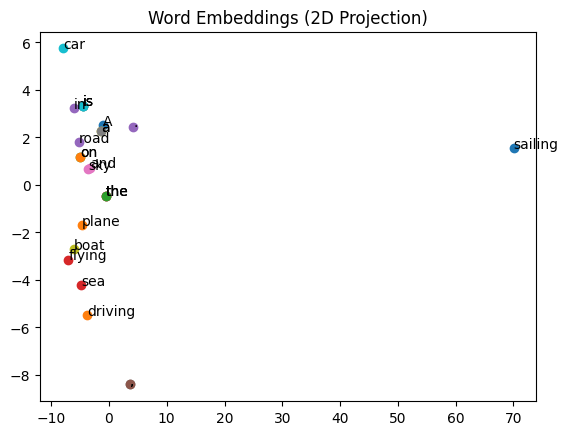

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

for i, word in enumerate(tokens):
    plt.scatter(points[i,0], points[i,1])
    plt.text(points[i,0]+0.01, points[i,1]+0.01, word)

plt.title("Word Embeddings (2D Projection)")
plt.show()

## Posistional Encoding

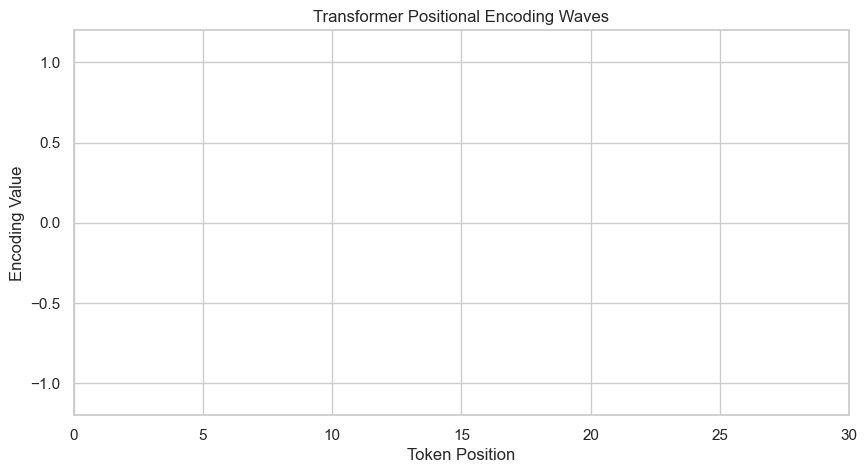

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# parameters
seq_len = 30
d_model = 32

# positional encoding
pos_encoding = np.zeros((seq_len, d_model))

for pos in range(seq_len):
    for i in range(0, d_model, 2):
        pos_encoding[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
        pos_encoding[pos, i+1] = np.cos(pos / (10000 ** (i / d_model)))

# plot setup
fig, ax = plt.subplots(figsize=(10,5))
lines = []
colors = plt.cm.viridis(np.linspace(0,1,6))

for i in range(6):
    line, = ax.plot([], [], color=colors[i], lw=2)
    lines.append(line)

ax.set_xlim(0, seq_len)
ax.set_ylim(-1.2,1.2)
ax.set_xlabel("Token Position")
ax.set_ylabel("Encoding Value")
ax.set_title("Transformer Positional Encoding Waves")

# animation function
def update(frame):
    x = np.arange(seq_len)
    
    for i,line in enumerate(lines):
        dim = i*2
        y = pos_encoding[:,dim]
        line.set_data(x[:frame], y[:frame])
        
    return lines

ani = FuncAnimation(fig, update, frames=seq_len, interval=100)

HTML(ani.to_jshtml())

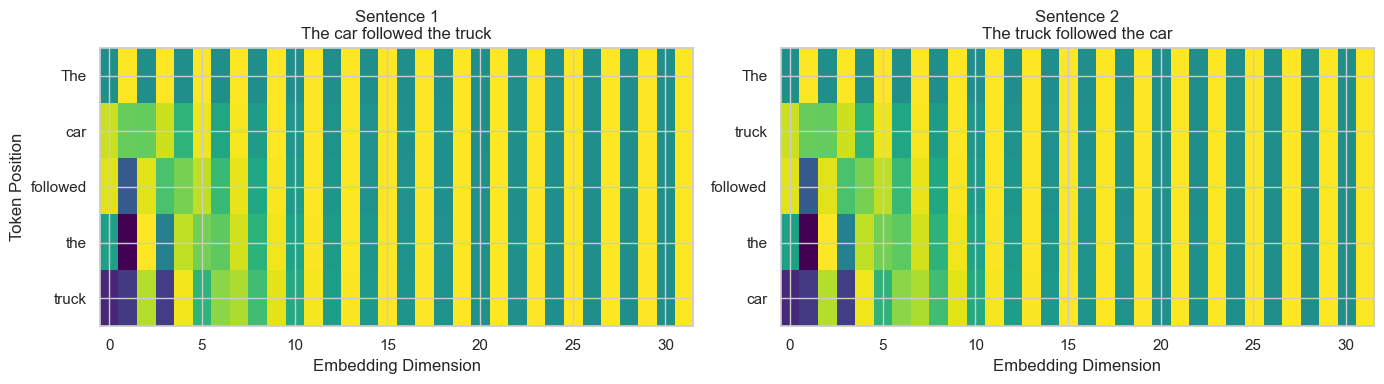

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# sentences
sentence1 = ["The","car","followed","the","truck"]
sentence2 = ["The","truck","followed","the","car"]

seq_len = len(sentence1)
d_model = 32

# positional encoding function
def positional_encoding(seq_len, d_model):
    pos_encoding = np.zeros((seq_len, d_model))
    
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            pos_encoding[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
            pos_encoding[pos, i+1] = np.cos(pos / (10000 ** (i / d_model)))
            
    return pos_encoding

pos_encoding = positional_encoding(seq_len, d_model)

# visualize
fig, axes = plt.subplots(1,2,figsize=(14,4))

axes[0].imshow(pos_encoding, aspect='auto', cmap='viridis')
axes[0].set_title("Sentence 1\nThe car followed the truck")
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(sentence1)
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Token Position")

axes[1].imshow(pos_encoding, aspect='auto', cmap='viridis')
axes[1].set_title("Sentence 2\nThe truck followed the car")
axes[1].set_yticks(range(seq_len))
axes[1].set_yticklabels(sentence2)
axes[1].set_xlabel("Embedding Dimension")

plt.tight_layout()
plt.show()

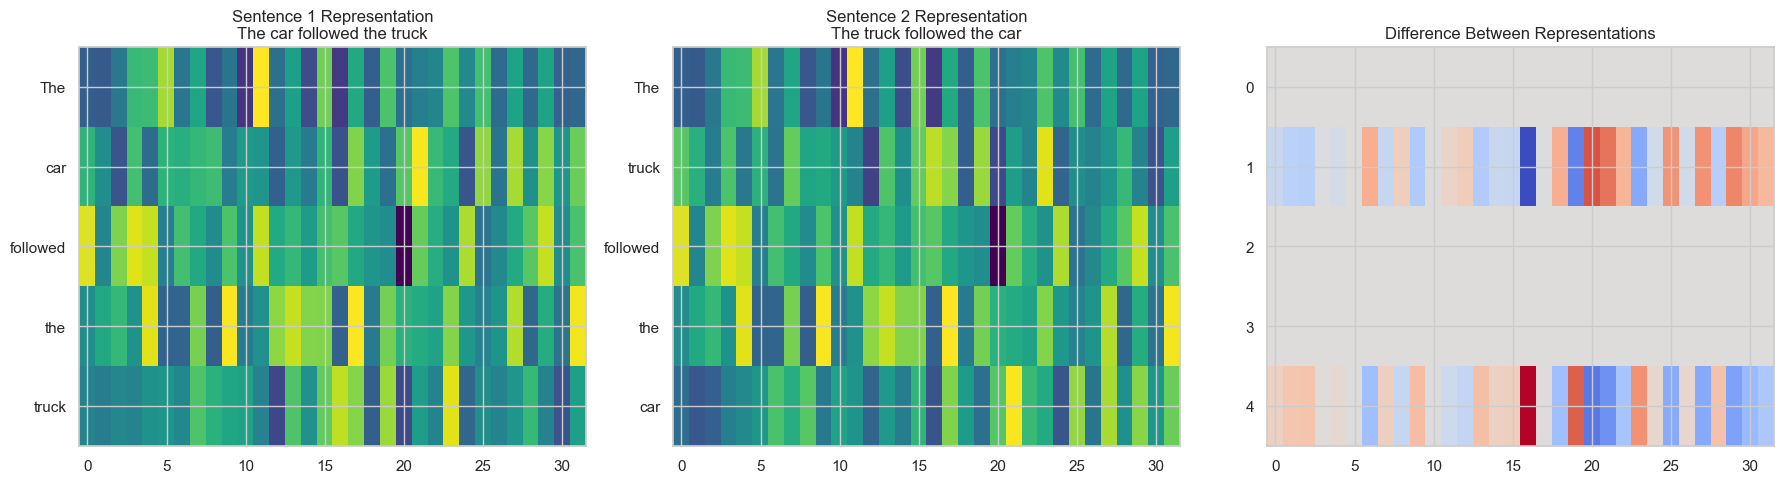

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sentences with same words but different order
sentence1 = ["The","car","followed","the","truck"]
sentence2 = ["The","truck","followed","the","car"]

seq_len = len(sentence1)
d_model = 32

# Positional Encoding
def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = np.sin(pos / (10000 ** (i/d_model)))
            pe[pos, i+1] = np.cos(pos / (10000 ** (i/d_model)))
            
    return pe

pos_encoding = positional_encoding(seq_len, d_model)

# Fake token embeddings
np.random.seed(0)
vocab = list(set(sentence1 + sentence2))
embeddings = {word: np.random.randn(d_model) for word in vocab}

# Build embedding matrices
emb_matrix1 = np.array([embeddings[w] for w in sentence1])
emb_matrix2 = np.array([embeddings[w] for w in sentence2])

# Add positional encoding
combined1 = emb_matrix1 + pos_encoding
combined2 = emb_matrix2 + pos_encoding

# Difference
difference = combined1 - combined2

# Plot
fig, axes = plt.subplots(1,3,figsize=(18,5))

axes[0].imshow(combined1, aspect="auto", cmap="viridis")
axes[0].set_title("Sentence 1 Representation\nThe car followed the truck")
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(sentence1)

axes[1].imshow(combined2, aspect="auto", cmap="viridis")
axes[1].set_title("Sentence 2 Representation\nThe truck followed the car")
axes[1].set_yticks(range(seq_len))
axes[1].set_yticklabels(sentence2)

axes[2].imshow(difference, aspect="auto", cmap="coolwarm")
axes[2].set_title("Difference Between Representations")

plt.tight_layout()
plt.show()

## Self Attention

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: improve plot aesthetics
sns.set(style="whitegrid")

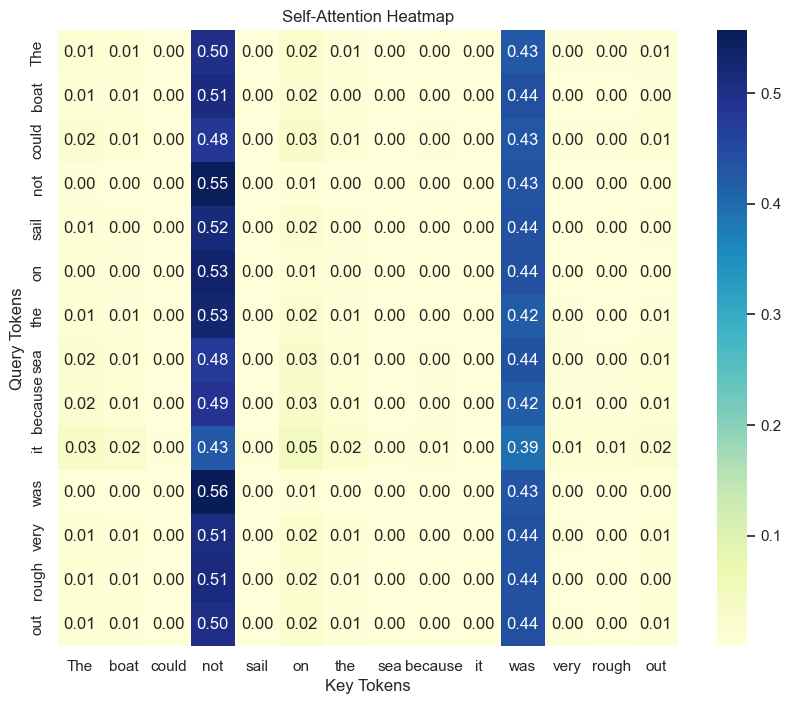

In [7]:
tokens = ["The", "boat", "could", "not", "sail", "on", "the", "sea", "because", "it", "was", "very", "rough", "out"]
num_tokens = len(tokens)
embedding_dim = 8

X = torch.rand(num_tokens, embedding_dim)

# Initialize weight matrices
W_q = torch.rand(embedding_dim, embedding_dim)
W_k = torch.rand(embedding_dim, embedding_dim)
W_v = torch.rand(embedding_dim, embedding_dim)

# Queries, Keys, Values
Q = X @ W_q
K = X @ W_k
V = X @ W_v

# Scaled dot-product attention
scores = Q @ K.T / (embedding_dim ** 0.5)
attention_weights = F.softmax(scores, dim=1)

# Output (optional)
output = attention_weights @ V

plt.figure(figsize=(10, 8))
sns.heatmap(attention_weights.detach().numpy(), xticklabels=tokens, yticklabels=tokens, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Self-Attention Heatmap")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()

In [18]:
from pyvis.network import Network
from IPython.display import IFrame
import numpy as np

attn = attention_weights.detach().numpy()

net = Network(height="600px", width="100%", directed=True, notebook=True, cdn_resources="in_line")

# Add nodes
for i, token in enumerate(tokens):
    net.add_node(i, label=token)

# Add edges
threshold = 0.1
for i in range(len(tokens)):
    for j in range(len(tokens)):
        weight = attn[i][j]
        if weight > threshold:
            net.add_edge(
                i,
                j,
                value=float(weight) * 10,
                title=f"{tokens[i]} → {tokens[j]}: {float(weight):.2f}"
            )

net.repulsion(node_distance=200)

# Write and display
net.write_html("attention.html")

## Training an LLM

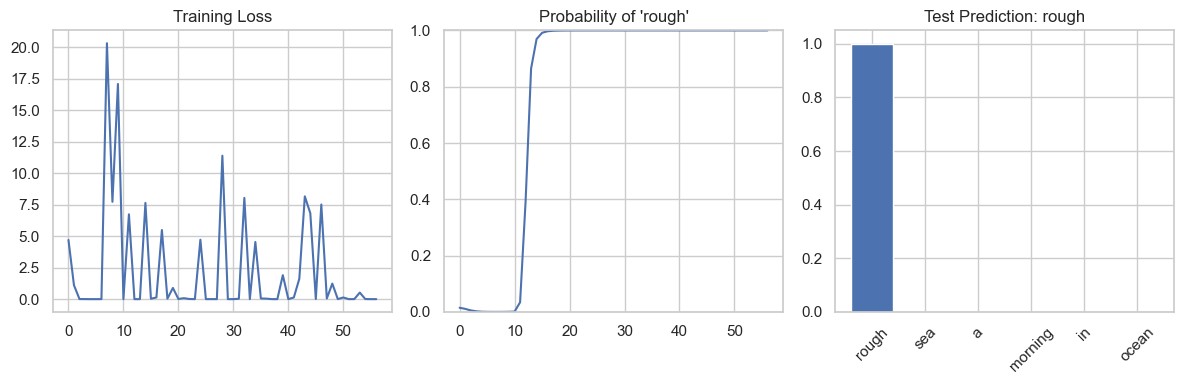

X: ['The', 'boat', 'could', 'not', 'sail', 'because', 'the', 'sea', 'was', 'very']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
import random
import time

training_data = [
# Rough ocean / storm conditions
("The boat could not sail because the sea was very","rough"),
("The ship could not sail because the sea was very","rough"),
("The ferry could not sail because the sea was very","rough"),
("The ocean waves were extremely","rough"),
("The sea during the storm was very","rough"),
("The wind made the ocean very","rough"),
("The storm made the sea extremely","rough"),
("The heavy wind made the waves","rough"),
("The strong storm made the water","rough"),
("The waves became very","rough"),
("The ocean conditions turned","rough"),
("The sea became extremely","rough"),
("The storm created very","rough"),
("The ocean today is very","rough"),
("The waves tonight are extremely","rough"),

# Calm water conditions
("The lake today is very","calm"),
("The lake this morning was perfectly","calm"),
("The quiet pond looked very","calm"),
("The lake became completely","calm"),
("The water in the bay was very","calm"),
("The small lake remained","calm"),
("The ocean early in the morning was","calm"),

# Weather patterns
("After the storm the wind became","calm"),
("The evening breeze was very","calm"),
("The wind slowly became","calm"),
("The air outside felt very","calm"),

# Nature scenes
("The forest was quiet and","calm"),
("The valley felt peaceful and","calm"),
("The mountain lake looked perfectly","calm"),

# Rough land / terrain
("The road through the mountains was very","rough"),
("The trail through the forest was extremely","rough"),
("The rocky path was very","rough"),
("The terrain became very","rough"),

# Mixed context examples
("The sailor said the sea looked","rough"),
("The captain warned the ocean was","rough"),
("The fisherman said the water felt","rough"),
("The lake after the storm became","rough"),
("It was really rough sailing on the","sea"),
("The boat struggled to sail through the rough","conditions"),
("Waves crashed against the shore in a very","rough"),
("The boat sailed smoothly on the","calm"),
("The lake was perfectly","calm"),
("The wind outside felt very","calm"),  
]

# Vocabulary
vocab = sorted(set(word for sent,_ in training_data for word in sent.split()) |
               set(target for _,target in training_data))

word_to_ix = {w:i for i,w in enumerate(vocab)}
ix_to_word = {i:w for w,i in word_to_ix.items()}

# Convert dataset to tensor 
data = []
for sent,target in training_data:
    words = sent.split()
    indices = torch.tensor([[word_to_ix[w] for w in words]])
    target_ix = torch.tensor([word_to_ix[target]])
    data.append((indices,target_ix))

context_len = max(len(s.split()) for s,_ in training_data)

def pad(seq):
    pad_len = context_len - seq.shape[1]
    if pad_len > 0:
        padding = torch.zeros((1,pad_len),dtype=torch.long)
        seq = torch.cat([seq,padding],dim=1)
    return seq

data = [(pad(x),y) for x,y in data]

# Test sentence
test_sentence = "The boat could not sail because the sea was very"
test_indices = torch.tensor([[word_to_ix[w] for w in test_sentence.split()]])
test_indices = pad(test_indices)


# Defining a Model
embedding_dim = 16

model = nn.Sequential(
    nn.Embedding(len(vocab), embedding_dim),
    nn.Flatten(),
    nn.Linear(context_len*embedding_dim,len(vocab))
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
loss_fn = nn.CrossEntropyLoss()

loss_history = []
rough_prob_history = []

# Training Loop
for step in range(150):

    x,y = random.choice(data)

    print("X:", [ix_to_word[ix.item()] for ix in x.flatten()])

    logits = model(x)
    loss = loss_fn(logits,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # Test prediction
    test_logits = model(test_indices)
    test_probs = F.softmax(test_logits,dim=1).detach().numpy()[0]

    rough_index = word_to_ix["rough"]
    rough_prob = test_probs[rough_index]

    rough_prob_history.append(rough_prob)

    predicted_word = ix_to_word[test_probs.argmax()]

    # Visualization
    clear_output(wait=True)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.plot(loss_history)
    plt.title("Training Loss")

    plt.subplot(1,3,2)
    plt.plot(rough_prob_history)
    plt.title("Probability of 'rough'")
    plt.ylim(0,1)

    plt.subplot(1,3,3)
    top = sorted(range(len(test_probs)), key=lambda i: test_probs[i], reverse=True)[:6]
    plt.bar([ix_to_word[i] for i in top],[test_probs[i] for i in top])
    plt.xticks(rotation=45)
    plt.title(f"Test Prediction: {predicted_word}")

    plt.tight_layout()
    plt.show()

    time.sleep(0.1)

print("Test Sentedce:", test_sentence)
print("Final Prediction:", predicted_word)